In [289]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [290]:
df=pd.read_csv('/Users/zoetankersley/sunrise_social_club/data/processed/sales_merged.csv')

In [291]:
df.head()

,Date,Time,Original_Item,Item,Base,Signature_Drink,Qty,Net_Sales,Size,Cold_Foam,Flavor,Avg_Temp,Weather_Condition,Event_Type,Location
0,2026-06-11,14:44:57,Matcha Latte,Matcha Latte,Whole Milk,False,1.0,9.0,16oz,1.0,Blueberry,84.0,Sunny,Popup,Islands Boutique
1,2026-06-11,14:43:02,Matcha Latte,Matcha Latte,NaN,False,1.0,7.0,12oz,0.0,Strawberry,84.0,Sunny,Popup,Islands Boutique
2,2026-06-11,14:39:31,Lemonade,Lemonade,Lemonade,False,2.0,10.0,16oz,0.0,Strawberry,84.0,Sunny,Popup,Islands Boutique
3,2026-06-11,14:31:49,Matcha Latte,Matcha Latte,Whole Milk,False,1.0,9.0,16oz,1.0,Blueberry,84.0,Sunny,Popup,Islands Boutique
4,2026-06-11,14:24:41,Matcha Latte,Matcha Latte,Oat Milk,False,1.0,9.0,16oz,1.0,Strawberry,84.0,Sunny,Popup,Islands Boutique


In [292]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 432 entries, 0 to 431
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Date               432 non-null    object 
 1   Time               432 non-null    object 
 2   Original_Item      432 non-null    object 
 3   Item               432 non-null    object 
 4   Base               247 non-null    object 
 5   Signature_Drink    432 non-null    bool   
 6   Qty                432 non-null    float64
 7   Net_Sales          432 non-null    float64
 8   Size               359 non-null    object 
 9   Cold_Foam          432 non-null    float64
 10  Flavor             332 non-null    object 
 11  Avg_Temp           428 non-null    float64
 12  Weather_Condition  428 non-null    object 
 13  Event_Type         428 non-null    object 
 14  Location           428 non-null    object 
dtypes: bool(1), float64(4), object(10)
memory usage: 47.8+ KB


In [293]:
df.groupby("Item")["Net_Sales"].sum().sort_values(ascending=False).head(10)

Item
Matcha Latte    2182.42
Cold Brew        694.00
Lemonade         345.00
Sticker           76.00
Name: Net_Sales, dtype: float64

In [294]:
df.groupby("Flavor")["Net_Sales"].sum().sort_values(ascending=False).head(10)

Flavor
Strawberry               1162.58
Blueberry                 533.00
Salted Maple              397.66
Cinn Roll                 231.00
Cake Batter               224.00
Vanilla                   114.00
No Syrup                   35.18
Strawberry, Blueberry      28.00
Name: Net_Sales, dtype: float64

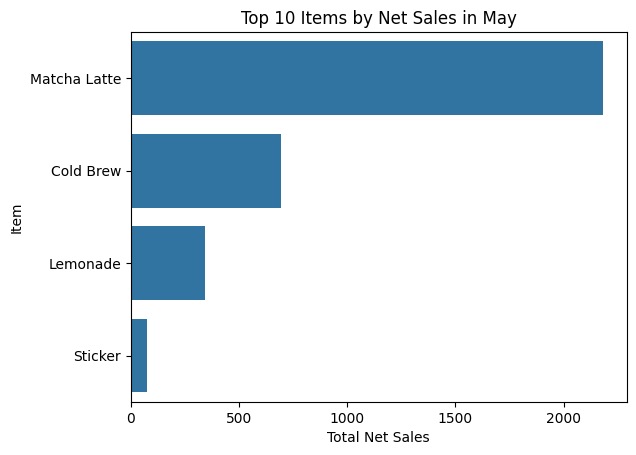

In [295]:
sns.barplot(x=df.groupby("Item")["Net_Sales"].sum().sort_values(ascending=False).head(10).values, y=df.groupby("Item")["Net_Sales"].sum().sort_values(ascending=False).head(10).index)
plt.xlabel("Total Net Sales")
plt.ylabel("Item")
plt.title("Top 10 Items by Net Sales in May")
plt.show()

In [296]:
df.groupby("Item")["Qty"].sum().sort_values(ascending=False).head(10)

Item
Matcha Latte    272.0
Cold Brew        97.0
Lemonade         76.0
Sticker          38.0
Name: Qty, dtype: float64

In [297]:
df.groupby("Event_Type")["Net_Sales"].sum().sort_values(ascending=False).head(10)

Event_Type
Market    2342.42
Popup      898.00
Name: Net_Sales, dtype: float64

In [298]:
df["Cold_Foam"].value_counts()

Cold_Foam
0.0    234
1.0    198
Name: count, dtype: int64

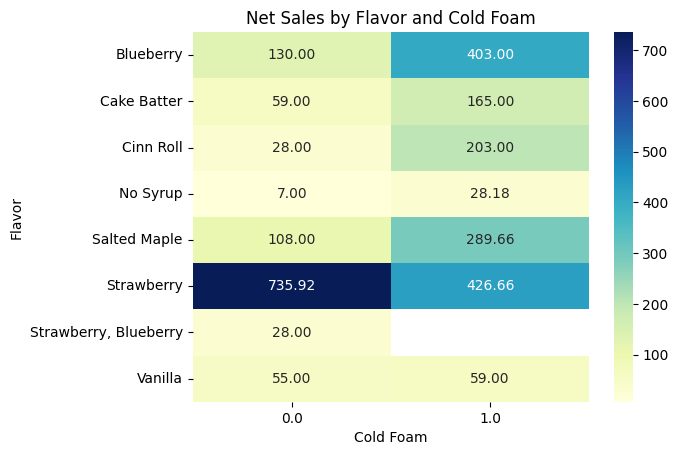

In [299]:
pivot = df.pivot_table(
    index="Flavor",
    columns="Cold_Foam",
    values="Net_Sales",
    aggfunc="sum"
)
sns.heatmap(pivot, annot=True, fmt=".2f", cmap="YlGnBu")
plt.title("Net Sales by Flavor and Cold Foam")
plt.xlabel("Cold Foam")
plt.ylabel("Flavor")
plt.show()

In [300]:
df["Flavor"].value_counts()

Flavor
Strawberry               143
Blueberry                 65
Salted Maple              49
Cinn Roll                 28
Cake Batter               23
Vanilla                   13
Strawberry, Blueberry      6
No Syrup                   5
Name: count, dtype: int64

In [301]:
df['Item'].unique()

array(['Matcha Latte', 'Lemonade', 'Sticker', 'Cold Brew'], dtype=object)

In [302]:
df["Signature_Drink"].value_counts()

Signature_Drink
False    408
True      24
Name: count, dtype: int64